In [20]:
from botorch.acquisition import qLogNoisyExpectedImprovement, qLogExpectedImprovement
from botorch.acquisition.objective import GenericMCObjective
from botorch.models import ModelListGP, SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from gpytorch.mlls import SumMarginalLogLikelihood
from botorch.optim import optimize_acqf
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

In [40]:
# --- Name constants --- #
INPUT = "input"
FLAT = "flat"
X50 = "50x50"
X15 = "15x15"
# --- Name mapping --- #
mapping = {
    FLAT: "Flat",
    X50: "Large pore",
    X15: "Small pore",
}
# --- Constraint constants --- #
V_LOW = 0.1
V_HIGH = 6
S_LOW = 0.1
S_HIGH = 10

In [3]:
import os
from pathlib import Path

In [36]:
"""Compute the oxygen concentration difference from COMSOL output txt"""
def get_delta(filepath):
    values = [] # x y z value
    with open(filepath, "r") as f:
        line_count = 0
        for l in f:
            line_count += 1
            if line_count < 9: continue # First 8 lines are headers
            
            line = l.split()
            row = [float(v) for v in line]
            values.append(row)
    values = np.array(values)
    
    # Get the first and last one-third section to calculate the difference
    first_sum = 0
    last_sum = 0
    first_count = 0
    last_count = 0
    
    x_min = np.min(values[:,0])
    x_max = np.max(values[:,0])
    p1 = x_min + (x_max-x_min)/3
    p2 = x_min + (x_max-x_min)*2/3
    for row in values:
        if row[0] < p1:
            first_sum += row[-1]
            first_count += 1
        elif row[0] > p2:
            last_sum += row[-1]
            last_count += 1
    
    first_avg = first_sum/first_count
    last_avg = last_sum/last_count
    delta = abs(first_avg - last_avg)
    print(f"First third average: {first_avg} over {first_count} points")
    print(f"Last third average: {last_avg} over {last_count} points")
    print(f"Delta: {delta}")
    return delta

In [45]:
# --- Parse all files --- #
directory = "data/samples" # Change directory here

deltas = {}
for filename in os.listdir(directory):
    if filename.endswith(".txt"):
        filepath = os.path.join(directory, filename)
        condition, x = Path(filepath).stem.split('_')
        condition = condition.lower()
        x = float(x)
        delta = get_delta(filepath)
        deltas.setdefault(x, {})[condition] = delta
print(deltas)

First third average: 2.220446049250313e-16 over 132923 points
Last third average: 2.220446049250313e-16 over 132817 points
Delta: 0.0
First third average: 0.11032509730327653 over 132923 points
Last third average: 2.220446049250313e-16 over 132817 points
Delta: 0.1103250973032763
First third average: 0.15511859549986015 over 132923 points
Last third average: 0.066263550841059 over 132817 points
Delta: 0.08885504465880115
First third average: 0.18742572519540643 over 132923 points
Last third average: 0.17575985144491027 over 132817 points
Delta: 0.011665873750496158
First third average: 0.177301326035903 over 132683 points
Last third average: 0.1401039125367246 over 132623 points
Delta: 0.037197413499178406
First third average: 0.17763336912206684 over 132683 points
Last third average: 0.14133184881707875 over 132623 points
Delta: 0.036301520304988094
First third average: 0.17792530256767616 over 132683 points
Last third average: 0.1424115561515053 over 132623 points
Delta: 0.0355137464

In [46]:
# --- Make dataframe --- #
data = []
for x in deltas.keys():
    d = deltas[x]
    data.append([x, d[FLAT], d[X50], d[X15]])
df = pd.DataFrame(data=data, columns=[INPUT,FLAT,X50,X15])
df.to_csv("data/output.csv", index=False)

# Bayesian optimization

In [42]:
# --- Set seed for reproducibility --- #
torch.manual_seed(42)

In [73]:
# --- Load bootstrap samples --- #
# Load csv as pandas dataframe
path_to_csv = "data/base.csv"  # Replace with your csv
df = pd.read_csv(path_to_csv)
#df = df[0:6]

# Init variables
X = torch.tensor(np.expand_dims(df.iloc[:,0],axis=1))
# Normalize input to unit
X_min = X.min(0, keepdim=True)[0]
X -= X_min
X_max = X.max(0, keepdim=True)[0]
X /= X_max
# Scalarize outputs from 3 conditions
Y_aug = torch.tensor(np.expand_dims(df.iloc[:,1:4].sum(axis=1)/3, axis=1))
# Collect constraints
C = torch.tensor(df.iloc[:,4:10].to_numpy())
# Ensure double
X = X.to(torch.double)
Y_aug = Y_aug.to(torch.double)
C = C.to(torch.double)

In [74]:
# --- Build joint surrogate: 1 objecive GP + 6 constraint GPs --- #
# X: (n,1) input oxygen flow rate 
# Y_aug: (n,1) scalarized objective using weighted sum
# C: (n,6) constraint outputs from simulation [v1, s1, v2, s2, v3, s3]

all_models = ModelListGP(
    SingleTaskGP(X, Y_aug),     # Objective
    SingleTaskGP(X, C[:,0:1]),  # velocity flat
    SingleTaskGP(X, C[:,1:2]),  # shear stress flat
    SingleTaskGP(X, C[:,2:3]),  # velocity 50x50
    SingleTaskGP(X, C[:,3:4]),  # shear stress 50x50
    SingleTaskGP(X, C[:,4:5]),  # velocity 15x15
    SingleTaskGP(X, C[:,5:6]),  # shear stress 15x15
)
mll = SumMarginalLogLikelihood(all_models.likelihood, all_models)
fit_gpytorch_mll(mll)

SumMarginalLogLikelihood(
  (likelihood): LikelihoodList(
    (likelihoods): ModuleList(
      (0-6): 7 x GaussianLikelihood(
        (noise_covar): HomoskedasticNoise(
          (noise_prior): LogNormalPrior()
          (raw_noise_constraint): GreaterThan(1.000E-04)
        )
      )
    )
  )
  (model): ModelListGP(
    (models): ModuleList(
      (0-6): 7 x SingleTaskGP(
        (likelihood): GaussianLikelihood(
          (noise_covar): HomoskedasticNoise(
            (noise_prior): LogNormalPrior()
            (raw_noise_constraint): GreaterThan(1.000E-04)
          )
        )
        (mean_module): ConstantMean()
        (covar_module): RBFKernel(
          (lengthscale_prior): LogNormalPrior()
          (raw_lengthscale_constraint): GreaterThan(2.500E-02)
        )
        (outcome_transform): Standardize()
      )
    )
    (likelihood): LikelihoodList(
      (likelihoods): ModuleList(
        (0-6): 7 x GaussianLikelihood(
          (noise_covar): HomoskedasticNoise(
         

In [75]:
# --- Define objective --- #
objective = GenericMCObjective(lambda samples, X=None: samples[...,0])

In [76]:
# --- Define constraints --- ##
# Constraints are a list of callables
# From botorch: The associated constraints are satisfied if `constraints(samples) < 0`.
constraints = {
    1: (V_LOW, V_HIGH),
    2: (S_LOW, S_HIGH),
    3: (V_LOW, V_HIGH),
    4: (S_LOW, S_HIGH),
    5: (V_LOW, V_HIGH),
    6: (S_LOW, S_HIGH),
}

constraint_callables = []
for idx, (low, high) in constraints.items():
    constraint_callables.append(lambda samples, i=idx, lo=low: lo - samples[..., i])
    constraint_callables.append(lambda samples, i=idx, hi=high: samples[..., i] - hi)

In [77]:
# --- Compute best feasible output--- #
best_feasible = -np.inf
best_input = -1
for i, c in enumerate(C):
    ok_count = 0
    for idx, (low, high) in constraints.items():
        col = c[idx-1]
        ok = (col >= low) & (col <= high)
        if ok: ok_count += 1
    if ok_count == len(c):
        if Y_aug[i] > best_feasible:
            best_feasible = Y_aug[i]
            best_input = X[i]

print(f"Best feasible value {best_feasible.item()}, Best input {best_input*X_max+X_min}")

Best feasible value 0.05131476233333334, Best input tensor([[2.6683]], dtype=torch.float64)


In [78]:
# --- Define acquisition function --- #
# Simulations are deterministic, we switch to qLogExpectedImprovement
acq_fn = qLogExpectedImprovement(
    model = all_models,
    best_f = best_feasible,
    objective = objective,
    constraints = constraint_callables,
)

In [79]:
# --- Optimize acquisition function to get next candidate --- #
X_low = 0.0
X_high = 1.0

candidate, acq_value = optimize_acqf(
    acq_function = acq_fn,
    bounds = torch.tensor([[X_low],[X_high]], dtype=X.dtype),
    q = 1,
    num_restarts = 10,
    raw_samples = 512,
)

candidate = candidate * X_max + X_min
print(f"Next candidate: {candidate.item()}, acq value: {acq_value.item():.4f}")

Next candidate: 2.57413608425847, acq value: -7.0024


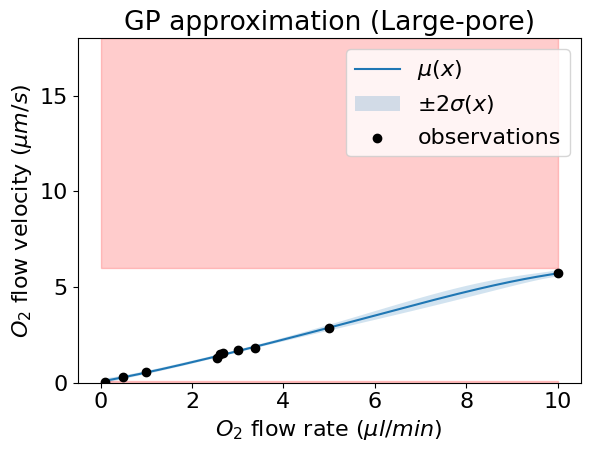

In [81]:
matplotlib.rcParams.update({'font.size': 16})
# --- Visualize GP for debugging --- #
X_test = torch.linspace(X_low, X_high, 200).unsqueeze(-1)

model_idx = 3 # Change index here to visualize objective or constraints
model = all_models.models[model_idx]

model.eval()
with torch.no_grad():
    posterior = model.posterior(X_test)
    mean = posterior.mean.squeeze()
    std = posterior.variance.squeeze().sqrt()

# Plot
fig, ax = plt.subplots()
X_coords = X_test * X_max + X_min # Recover original input scale
ax.plot(X_coords.squeeze().numpy(), mean.numpy(), label="$\\mu(x)$")
ax.fill_between(
    X_coords.squeeze().numpy(),
    (mean - 2 * std).numpy(),
    (mean + 2 * std).numpy(),
    alpha = 0.2,
    label = "±2$\\sigma(x)$"
)

X_coords = X.squeeze() * X_max + X_min # Recover original input scale
if model_idx == 0:
    ax.scatter(X_coords.numpy(), Y_aug.squeeze().numpy(), c="black", zorder=3, label="observations")
else:
    ax.scatter(X_coords.numpy(), C[:,model_idx-1].numpy(), c="black", zorder=3, label="observations")

# Constraint regions
if model_idx > 0:
    y_max = (mean + 2 * std).max().item()
    if model_idx % 2 == 1: # velocity
        ax.fill_between([0,10], [0,0], [V_LOW, V_LOW], alpha=0.2, color="r")
        ax.fill_between([0,10], [V_HIGH,V_HIGH], [18, 18], alpha=0.2, color="r")
    else: # shear stress
        ax.fill_between([0,10], [0,0], [S_LOW, S_LOW], alpha=0.2, color="r")
        if y_max > S_HIGH: ax.fill_between([0,10], [S_HIGH,S_HIGH], [y_max, y_max], alpha=0.2, color="r")

title = "GP approximation"
if model_idx > 0:
    if model_idx < 3: title += " (Flat)"
    elif model_idx < 5: title += " (Large-pore)"
    else: title += " (Small-pore)"
ax.set_title(title)
ax.set_xlabel("$O_2$ flow rate ($\\mu l/min$)")
if model_idx > 0:
    if model_idx % 2 == 1: # velocity
        ax.set_ylabel("$O_2$ flow velocity ($\\mu m/s$)")
        ax.set_ylim([0,18])
    else:
        ax.set_ylabel("Shear stress (mpa)")
        ax.set_ylim([0,1.0])
else:
    ax.set_ylabel("$O_2$ concentration delta ($mol/m^3$)")

ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

# Synthetic data for testing

In [95]:
# --- Synthetic test data --- #
# amp: changes the synthetic data generator for the three conditions
# 1.0: condition 1, 2.0: condition 2, 3.0 condition 3
def compute_difference(in_flow, amp=1.0):
    x = in_flow
    return 1/(1+np.exp(-0.2*amp*(x-5*amp)))+0.5*np.sin(x)-0.02*x+5

def compute_velocity(in_flow, amp=1.0):
    x = in_flow
    return np.sqrt(x)+0.5*amp*np.cos(x)

def compute_ss(in_flow, amp = 1.0):
    x = in_flow
    return (2*x**2)/np.exp(x)+0.3/amp*np.sin(x)+0.3*x

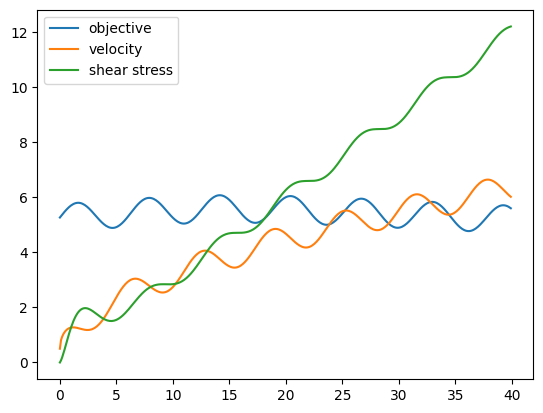

In [96]:
# --- Visualize the functions for flat condition --- #
X = np.arange(0,40,0.1)
plt.plot(X, compute_difference(X), label="objective")
plt.plot(X, compute_velocity(X), label="velocity")
plt.plot(X, compute_ss(X), label="shear stress")
plt.legend()

In [97]:
# --- Make synthetic data --- #
X = np.random.rand(12)*40
data = []
for x in X:
    row = [x]
    for i in range(1,4,1):
        row.append(compute_difference(x, amp=i))
    for i in range(1,4,1):
        row.append(compute_velocity(x, amp=i))
        row.append(compute_ss(x, amp=i))
    data.append(row)
data = np.array(data)

In [98]:
df = pd.DataFrame(data=data, columns=[INPUT,FLAT,X50,X15,"v_flat","s_flat","v_50","s_50","v_15","s_15"])
df.to_csv("test.csv", index=False)
df

,input,Flat,50x50,15x15,v_flat,s_flat,v_50,s_50,v_15,s_15
0,13.604483,6.006878,5.967366,5.460736,3.942349,4.340236,4.196273,4.211019,4.450196,4.167947
1,32.459026,5.778701,5.782679,5.782776,5.949055,9.996898,6.200827,9.867303,6.452600,9.824105
2,12.883848,5.727155,5.658565,5.117719,4.064421,3.959649,4.539434,3.912823,5.014447,3.897214
3,11.489254,5.115390,4.974590,4.438389,3.626515,3.185301,3.863450,3.317390,4.100384,3.361420
4,22.786453,5.159507,5.181260,5.177964,4.423482,6.621713,4.073449,6.728825,3.723415,6.764528
5,17.274688,5.075432,5.102843,4.951051,4.154247,4.882428,4.152212,5.032426,4.150176,5.082426
6,39.871822,5.613756,5.614684,5.614690,6.031303,12.208823,5.748193,12.085185,5.465082,12.043972
7,37.052599,4.956103,4.957725,4.957743,6.486179,10.935057,6.885274,11.025419,7.284368,11.055539
8,7.787620,5.979027,5.635300,5.356176,2.823787,2.685943,2.856943,2.536273,2.890100,2.486384
9,27.681294,5.715216,5.724969,5.725320,4.846679,8.472054,4.432056,8.388221,4.017433,8.360277
